In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns


In [2]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 156 (delta 50), reused 29 (delta 5), pack-reused 18 (from 2)
Receiving objects: 100% (156/156), 209.83 MiB | 23.39 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Updating files: 100% (46/46), done.
Filtering content: 100% (14/14), 1.29 GiB | 46.02 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [3]:
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [4]:
X_train_knn_pca=unpickle("PreProcessedData/TrainFeaturesPCA.pkl")
print(X_train_knn_pca.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_knn_pca=unpickle("PreProcessedData/TestFeaturesPCA.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 658)
(50000,)


In [5]:
# Flattening the image
X_train_knn_pca = X_train_knn_pca.reshape(50000, -1)
X_test_knn_pca = X_test_knn_pca.reshape(10000, -1)

print(X_train_knn_pca.shape)
print(X_test_knn_pca.shape)

(50000, 658)
(10000, 658)


Writing our own KNN Implementation

In [6]:
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def find_knn(k=10, X_train=X_train_knn_pca, X_test=X_test_knn_pca, y_train=y_train, y_test=y_test):
    correct = 0
    results = []

    for idx, test_sample in enumerate(tqdm(X_test)):
        # Compute distances in a vectorized way
        distances = np.linalg.norm(X_train - test_sample, axis=1)

        # Get indices of k smallest distances
        k_nearest_indices = np.argsort(distances)[:k]

        # Get labels of k nearest neighbors
        k_labels = y_train[k_nearest_indices]

        # Majority vote for classification
        predicted_label = Counter(k_labels).most_common(1)[0][0]
        results.append(predicted_label)

        # Accuracy calculation
        if predicted_label == y_test[idx]:
            correct += 1

    # Print accuracy
    accuracy = correct / len(X_test)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, results)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Custom k-NN (Euclidean)")
    plt.show()




100%|██████████| 10000/10000 [39:17<00:00,  4.24it/s]


Accuracy: 35.37%
Confusion Matrix:
 [[489   3 102  12  64   4  34   5 283   4]
 [ 76 177  94  37 175  30 100  11 263  37]
 [ 76   0 401  42 289  31  81   9  67   4]
 [ 42   3 184 166 232 119 167  19  63   5]
 [ 41   0 224  22 565  16  57  18  57   0]
 [ 33   1 177 120 218 253 114  17  59   8]
 [ 10   0 218  39 342  24 333   2  31   1]
 [ 61   3 152  41 294  54  68 237  81   9]
 [ 80   6  34  34  78  15  16   9 723   5]
 [ 96  30  70  44 130  23  71  27 316 193]]


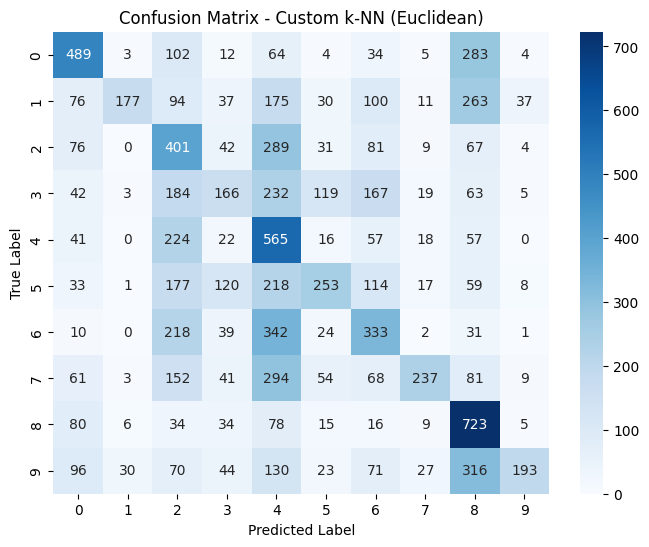

In [7]:
find_knn()

using SkLearn Library with Euclidean as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

def find_knn1(k=10, X_train=X_train_knn_pca, X_test=X_test_knn_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(accuracy)
           # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


0.3434
Confusion Matrix:
 [[516   3 108  16  59   3  28   5 262   0]
 [107 197 127  37 171  24  80   7 229  21]
 [107   1 436  38 265  29  63   5  54   2]
 [ 52   3 229 188 234  94 133  11  52   4]
 [ 54   1 261  21 543  13  43  14  50   0]
 [ 44   4 210 135 223 214  98  13  53   6]
 [ 20   0 271  54 325  23 280   0  26   1]
 [ 73   7 179  52 294  53  53 206  75   8]
 [112   7  39  38  71  13  14   7 694   5]
 [124  37 100  42 129  23  60  21 304 160]]


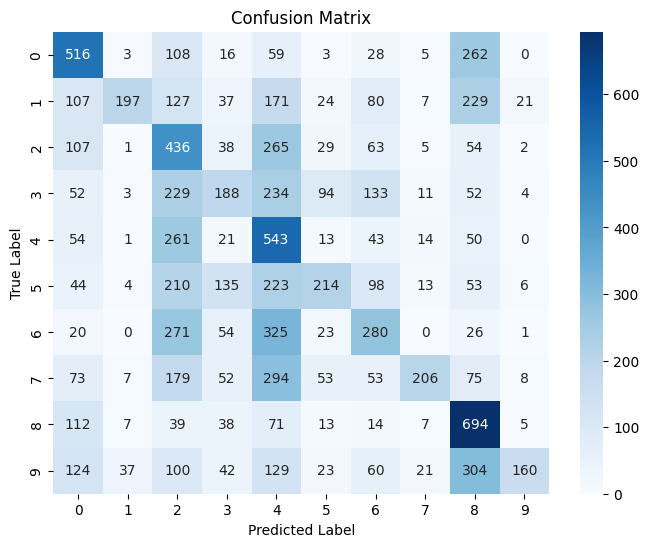

In [ ]:
find_knn1()

using SkLearn Library with Manhattan as the distance metric

Confusion Matrix:
 [[450   0  56   6  71   1   4   0 412   0]
 [105  29 115  25 287  14  11   0 414   0]
 [185   0 266  35 347   8  14   0 145   0]
 [166   0 179 116 319  30  22   0 168   0]
 [112   0 130  20 605   3   9   0 121   0]
 [153   0 208 109 293  79  12   0 146   0]
 [ 65   0 192  47 523   8  67   0  98   0]
 [116   0 135  35 407  27   9  35 236   0]
 [133   0  16  15  89   7   3   0 737   0]
 [ 89   0  64  12 207   5   9   1 612   1]]


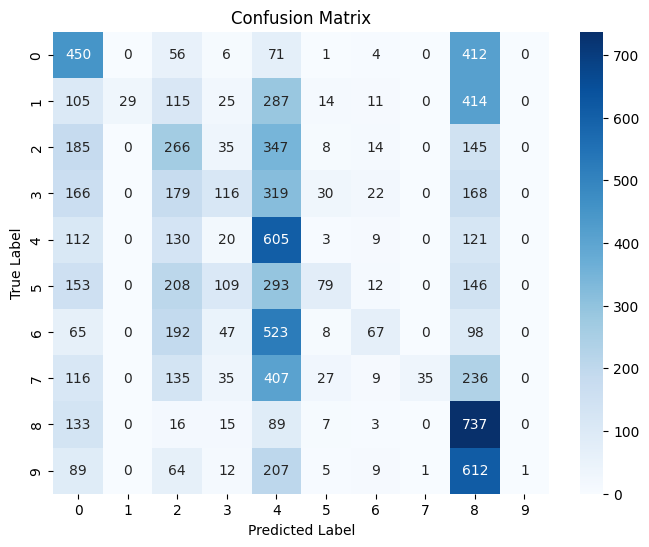

0.2385


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

def find_knn2(k=10, X_train=X_train_knn_pca, X_test=X_test_knn_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Manhattan distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
               # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy

accuracy = find_knn2()
print(accuracy)


using SkLearn Library with Canberra as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def find_knn3(k=10, X_train=X_train_knn_pca, X_test=X_test_knn_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Canberra distance metric
    knn = KNeighborsClassifier(n_neighbors=k, metric='canberra')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(accuracy)
    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


0.3897
Confusion Matrix:
 [[593  74  71  32  23  23  20  28 112  24]
 [ 97 593  25  32   9  30  28  40  50  96]
 [150  56 404  76  85  69  57  44  34  25]
 [131 102 142 220  74 119  57  76  39  40]
 [126  68 156  78 311  67  57  79  40  18]
 [100  76 143 191  79 230  43  93  21  24]
 [116 109 119  85  86  72 310  49  28  26]
 [ 71 116  83  68  67  67  29 449  13  37]
 [216  90  36  42  19  24  16  21 506  30]
 [116 267  35  58  19  49  39  64  72 281]]


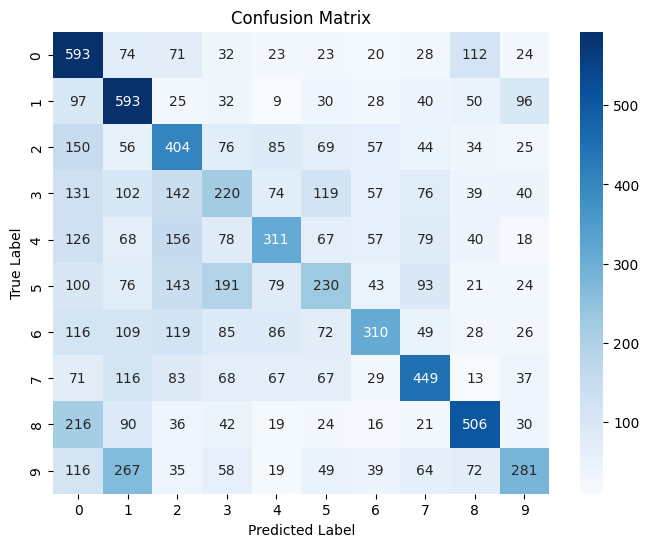

In [ ]:
find_knn3()

using SkLearn Library with Bray Curtis as the distance metric

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def find_knn4(k=10, X_train=X_train_knn_pca, X_test=X_test_knn_pca, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Bray-Curtis distance metric
    knn = KNeighborsClassifier(n_neighbors=k, metric='braycurtis')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(accuracy)
               # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


0.539
Confusion Matrix:
 [[678  26  50  26  16   7  14  11 142  30]
 [ 40 688  11  26  12  12  18  10  84  99]
 [ 97  32 474  97 106  60  53  35  32  14]
 [ 53  48 108 387  67 180  65  39  23  30]
 [ 71  17 186  81 437  48  54  68  22  16]
 [ 39  24  95 236  59 415  42  45  27  18]
 [ 21  46  96 107  97  62 520  21  15  15]
 [ 48  25  47  76  78  73  15 584  18  36]
 [113  59  15  26  21  15   5  14 699  33]
 [ 50 202  14  42  14  23  21  33  93 508]]


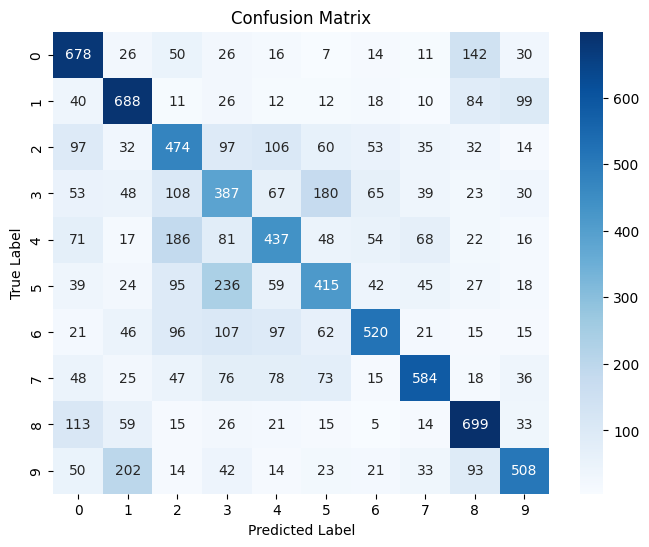

In [9]:
find_knn4()